# Long Short-Term Memory models for ECG data

In this notebook, we are having a look at data in form of a **series or sequence**. In medical practice, besides text, time series data is one of the most common data types. Time series data are measurements collected over time, so the **order of values matters**. Unlike tabular data, samples are not independent features, they form a sequence where earlier values can influence later ones.

ECG5000 is a univariate time-series dataset in which 5,000 patients' heartbeats were extracted from a 20-hour ECG recording. Each patients ECG was resampled to 140 time steps. The datset is part of the [UCR Time Series Archive](https://www.cs.ucr.edu/%7Eeamonn/time_series_data_2018/) and labels each heartbeat into five morphology-based classes (one majority normal class and four abnormal subclasses), making it a standard benchmark for sequence models.

Goal:
- Load [ECG](https://en.wikipedia.org/wiki/Electrocardiography) data from ECG5000
- Train an Long-Short-Term memory (LSTM) model to classify patients into 5 categories
- Evaluate performance

In [ ]:
from google.colab import ai
response = ai.generate_text("Tell me what AI you are and can you help me with coding problems?")
print(response)

I am a large language model, trained by Google.

**Yes, absolutely! I can help you with a wide range of coding problems.**

Here's how I can assist you:

1.  **Code Generation:** I can write code snippets, functions, or even small scripts in many programming languages (Python, JavaScript, Java, C++, Ruby, Go, SQL, HTML/CSS, etc.) based on your descriptions.
2.  **Debugging:** If you have code that isn't working, you can paste it to me, explain the error message or unexpected behavior, and I can often help identify the issue and suggest fixes.
3.  **Code Explanation:** I can explain how specific pieces of code work, break down complex algorithms, or clarify confusing syntax.
4.  **Concept Explanation:** I can explain programming concepts, data structures, algorithms, design patterns, and best practices.
5.  **Refactoring and Optimization:** I can suggest ways to improve existing code for readability, efficiency, or adherence to best practices.
6.  **Learning a New Language/Framework:** 

In [ ]:
!pip -q install tslearn umap-learn

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, Dataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, f1_score
from sklearn.metrics import roc_curve, roc_auc_score, auc, confusion_matrix, ConfusionMatrixDisplay

from sklearn.decomposition import PCA
import umap

from tslearn.datasets import UCR_UEA_datasets

## 1) Load ECG5000 dataset and split into train/validation/test

We use the `UCR_UEA_datasets` package, which provides programmatic access to ECG5000 cohorts as pandas DataFrames. Lets see what data we have available in this package.

In [ ]:
ucr = UCR_UEA_datasets()

X_train, y_train, X_test, y_test = ucr.load_dataset("ECG5000")

X_all = np.concatenate([X_train, X_test], axis=0)
y_all = np.concatenate([y_train, y_test], axis=0)
y_all_bin = (y_all != 1).astype(np.int64)  # 0=healthy, 1=rest

print("5-class class counts:", np.unique(y_all, return_counts=True))
print("2-class class counts:", np.unique(y_train2, return_counts=True))

Train: (3000, 140, 1) Val: (1000, 140, 1) Test: (1000, 140, 1)
5-class class counts: (array([1, 2, 3, 4, 5]), array([2919, 1767,   96,  194,   24]))
2-class class counts: (array([0, 1]), array([1751, 1249]))


In this dataset, the classes are very uneven: class 1 and 2 contain most samples, while classes 3–5 are rare (e.g., only 14 samples for class 5 in the training set). This is called **class imbalance** and it can bias the model toward predicting the frequent classes, because that minimizes the loss most of the time.

To handle imbalance, we often (i) use metrics beyond accuracy (e.g., per-class recall / macro-F1), (ii) weight the loss by class frequency, or (iii) use sampling strategies (e.g., oversampling rare classes) so the model sees minority classes more often during training. For simplicity we here classify healthy vs. malignant.

**Exercise 1:** Please carry out the data split into train, validation and test. You can use the AI or have a look at the [solutions.ipynb](https://colab.research.google.com/drive/1z_G9J6AL7rz7X4f6coGeLymBq_5zq5bH#scrollTo=z368LGQnRlAn).

In [ ]:
X_train2, X_temp, y_train2, y_temp = train_test_split(
    X_all, y_all_bin, test_size=0.4, random_state=42, stratify=y_all_bin
)

X_val, X_test2, y_val, y_test2 = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

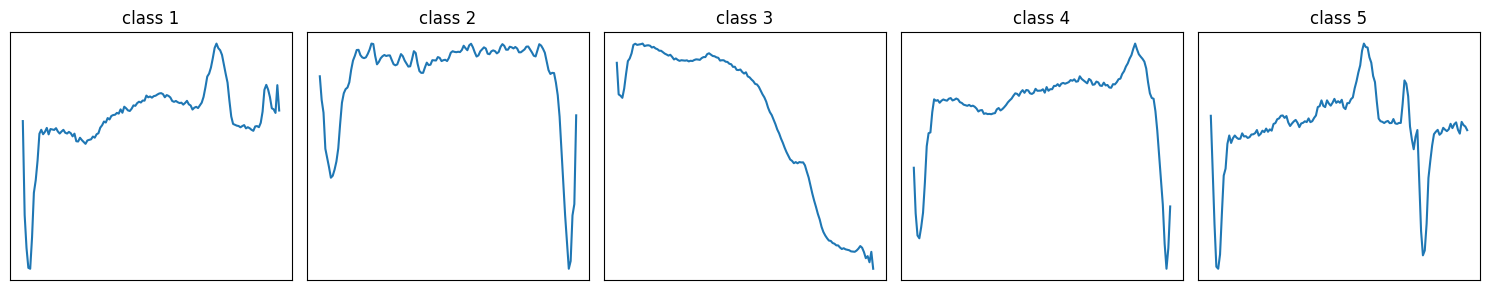

In [ ]:
classes = np.unique(y_train)

idxs = [np.where(y_train == c)[0][0] for c in classes]

plt.figure(figsize=(15, 3))
for i, (c, idx) in enumerate(zip(classes, idxs)):
    plt.subplot(1, len(classes), i + 1)
    plt.plot(X_train[idx, :, 0])
    plt.title(f"class {c}")
    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()

## 2) Write the data loader

In [ ]:
class ECGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

bs = 64

train_ds = ECGDataset(X_train2, y_train2)
val_ds   = ECGDataset(X_val, y_val)
test_ds  = ECGDataset(X_test2, y_test2)

train_loader = DataLoader(train_ds, batch_size=bs, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=bs, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=bs, shuffle=False)

## 3) Define a LSTM

**LSTMs** are a special type of recurrent neural network designed to learn from sequential data while avoiding the **vanishing gradient problem** that limits standard RNNs. The vanishing gradient problem refers to the situation where gradients become extremely small as they are backpropagated through many time steps, making it very hard for standard networks to learn **long-range dependencies**. They use internal **memory cells** and **gating mechanisms** (input, forget, and output gates) to decide what information to keep, update, or discard over long time spans, which makes them well suited for tasks like ECG analysis, language modeling, and time-series forecasting.

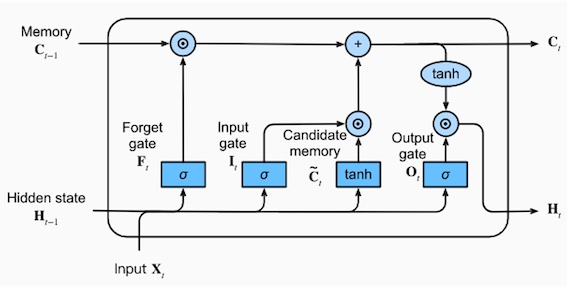

In [ ]:
class LSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_classes=5):
        super().__init__()
        self.hidden_size = hidden_size

        self.W_ih = nn.Parameter(torch.randn(input_size, 4 * hidden_size) * 0.1)
        self.W_hh = nn.Parameter(torch.randn(hidden_size, 4 * hidden_size) * 0.1)
        self.b_ih = nn.Parameter(torch.zeros(4 * hidden_size))
        self.b_hh = nn.Parameter(torch.zeros(4 * hidden_size))

        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        B, T, _ = x.shape
        H = self.hidden_size

        h = torch.zeros(B, H, device=x.device)
        c = torch.zeros(B, H, device=x.device)

        for t in range(T):
            x_t = x[:, t, :]

            gates = x_t @ self.W_ih + self.b_ih + h @ self.W_hh + self.b_hh
            i, f, g, o = gates.chunk(4, dim=1)

            i = torch.sigmoid(i)
            f = torch.sigmoid(f)
            g = torch.tanh(g)
            o = torch.sigmoid(o)

            c = f * c + i * g
            h = o * torch.tanh(c)

        logits = self.fc(h)
        return logits

## 4) Training loop



In [ ]:
device = torch.device("cpu")
print("Device:", device)

model = LSTM(input_size=1, hidden_size=64, num_classes=2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

Device: cpu


**Exercise 2:** Please write the training loop method `run_epoch()`. You can have a look at previous examples. The method should set the model to training mode, load the data and labels to the GPU, set your optimizer, calculate the loss, do backtracking and make a step with the optimizer. Also check which input parameters are using in the loop below.

In [ ]:
num_epochs = 20

train_losses = []
val_losses = []

for epoch in range(1, num_epochs + 1):
    tr_loss = run_epoch(model, train_loader, criterion, optimizer=optimizer, device=device)
    va_loss = run_epoch(model, val_loader, criterion, optimizer=None, device=device)

    train_losses.append(tr_loss)
    val_losses.append(va_loss)

    if epoch == 1 or epoch % 10 == 0 or epoch == num_epochs:
        print(f"Epoch {epoch:03d}/{num_epochs} | train_loss={tr_loss:.4f} | val_loss={va_loss:.4f}")

Epoch 001/20 | train_loss=0.4521 | val_loss=0.2418
Epoch 010/20 | train_loss=0.1874 | val_loss=0.1949
Epoch 020/20 | train_loss=0.0776 | val_loss=0.0657


## 5) Plot prediction loss

**Exercise 3:** Make a graph about the training and validation loss over the epochs.

## 6) Evaluate Model Performance

In [ ]:
model.eval()
all_probs, all_true = [], []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = model(xb)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        all_probs.append(probs)
        all_true.append(yb.cpu().numpy())

y_prob = np.vstack(all_probs)
y_true = np.concatenate(all_true)
y_pred = y_prob.argmax(axis=1)

**Exercise 4:** Print some summary statistics about the model on the test set. Please also display the confusion matrix and the roc curve.

## 7) Task specific metrics

We compute ROC AUC as a function of the observed **time window** to measure how well the model can classify sequences when only an **early part of the signal** is available. This gives an “early prediction” view of performance and shows how discrimination improves as more time points are observed.

In [ ]:
@torch.no_grad()
def collect_probs_on_prefix(model, loader, prefix_len, device):
    model.eval()
    probs_all, y_all = [], []

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.cpu().numpy()

        xb = xb[:, :prefix_len, :]
        logits = model(xb)
        probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()

        probs_all.append(probs)
        y_all.append(yb)

    return np.concatenate(probs_all), np.concatenate(y_all)

def auc_over_prefixes(model, loader, device, fractions=(0.1, 0.2, 0.3, 0.5, 0.7, 1.0)):
    xb0, _ = next(iter(loader))
    T = xb0.shape[1]
    results = []

    for frac in fractions:
        L = max(2, int(T * frac))
        y_prob_pos, y_true = collect_probs_on_prefix(model, loader, L, device=device)

        auc = roc_auc_score(y_true, y_prob_pos)
        results.append((frac, L, auc))

    return results


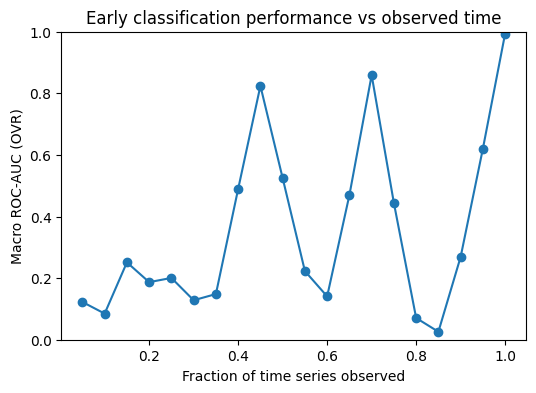

frac=0.05  prefix_len=   7  macro_auc=0.123
frac= 0.1  prefix_len=  14  macro_auc=0.085
frac=0.15000000000000002  prefix_len=  21  macro_auc=0.251
frac= 0.2  prefix_len=  28  macro_auc=0.187
frac=0.25  prefix_len=  35  macro_auc=0.201
frac= 0.3  prefix_len=  42  macro_auc=0.128
frac=0.35000000000000003  prefix_len=  49  macro_auc=0.148
frac= 0.4  prefix_len=  56  macro_auc=0.489
frac=0.45  prefix_len=  63  macro_auc=0.824
frac= 0.5  prefix_len=  70  macro_auc=0.525
frac=0.55  prefix_len=  77  macro_auc=0.223
frac=0.6000000000000001  prefix_len=  84  macro_auc=0.141
frac=0.6500000000000001  prefix_len=  91  macro_auc=0.469
frac=0.7000000000000001  prefix_len=  98  macro_auc=0.859
frac=0.7500000000000001  prefix_len= 105  macro_auc=0.444
frac= 0.8  prefix_len= 112  macro_auc=0.071
frac=0.8500000000000001  prefix_len= 119  macro_auc=0.026
frac=0.9000000000000001  prefix_len= 126  macro_auc=0.269
frac=0.9500000000000001  prefix_len= 133  macro_auc=0.620
frac= 1.0  prefix_len= 140  macro_au

In [ ]:
fractions = np.arange(0.05, 1.01, 0.05)
res = auc_over_prefixes(model, test_loader, device=device, fractions=fractions)

plt.figure(figsize=(6,4))
plt.plot([r[0] for r in res], [r[2] for r in res], marker="o")
plt.xlabel("Fraction of time series observed")
plt.ylabel("Macro ROC-AUC (OVR)")
plt.title("Early classification performance vs observed time")
plt.ylim(0.0, 1.0)
plt.show()

for frac, L, a in res:
    print(f"frac={frac:>4}  prefix_len={L:>4}  macro_auc={a:.3f}")

The AUC over prefixes is quite unstable, which suggests that the model’s performance depends strongly on which part of the sequence is included. When we look at example signals per class, we can see regions where classes share a similar shape and regions with class-specific patterns. Prefixes that capture a discriminative region tend to give higher AUC, while prefixes dominated by shared-looking segments lead to lower AUC. Overall, this supports the idea that the predictive signal is localized in time, rather than being evenly present throughout the sequence.